# Vision Transformer Pneumonia Classification

Pretrained ViT-B/16 for patient-level binary pneumonia classification on the RSNA Pneumonia Detection Challenge dataset. The notebook uses a fixed stratified patient split, validation-based model and threshold selection, held-out test evaluation, and self-attention visualization.


## 1. Setup and Configuration

### 1.1 Imports and reproducibility


In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python environment ready")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python environment ready
PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


### 1.2 Paths and experiment configuration


In [2]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4
NUM_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 1e-4
LR_PATIENCE = 1
LR_FACTOR = 0.5

DATA_ROOT = Path("/kaggle/input/datasets/rutujapadmakarlahane/rsna-pneumonia-classification")
METADATA_PATH = DATA_ROOT / "clean_classification_metadata.csv"
LABELS_PATH = DATA_ROOT / "stage_2_train_labels.csv"
IMAGE_DIR = DATA_ROOT / "stage_2_train_images" / "stage_2_train_images"

OUTPUT_DIR = Path("/kaggle/working/rsna_outputs/vit")
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
EXPLAIN_DIR = OUTPUT_DIR / "explainability"
CACHE_DIR = Path("/kaggle/working/rsna_image_cache")

for directory in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, EXPLAIN_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "vit_b16_best.pth"
LAST_MODEL_PATH = MODEL_DIR / "vit_b16_last.pth"
HISTORY_PATH = OUTPUT_DIR / "training_history.csv"
THRESHOLD_PATH = OUTPUT_DIR / "selected_threshold.json"

print("Clean metadata:", METADATA_PATH)
print("Training labels:", LABELS_PATH)
print("Training images:", IMAGE_DIR)
print("Output directory:", OUTPUT_DIR)


Clean metadata: /kaggle/input/datasets/rutujapadmakarlahane/rsna-pneumonia-classification/clean_classification_metadata.csv
Training labels: /kaggle/input/datasets/rutujapadmakarlahane/rsna-pneumonia-classification/stage_2_train_labels.csv
Training images: /kaggle/input/datasets/rutujapadmakarlahane/rsna-pneumonia-classification/stage_2_train_images/stage_2_train_images
Output directory: /kaggle/working/rsna_outputs/vit


## 2. Preprocessing

### 2.1 Load metadata and recreate the patient-level split

The split is stratified by the binary target and fixed with seed 42. Patients are mutually exclusive across train, validation and test sets.


In [3]:
metadata = pd.read_csv(METADATA_PATH)
metadata["patientId"] = metadata["patientId"].astype(str)
metadata["Target"] = metadata["Target"].astype(int)
metadata["image_path"] = metadata["patientId"].apply(lambda x: str(IMAGE_DIR / f"{x}.dcm"))

missing_images = (~metadata["image_path"].apply(lambda p: Path(p).is_file())).sum()

assert metadata["patientId"].nunique() == len(metadata)
assert missing_images == 0
assert set(metadata["Target"].unique()) == {0, 1}

train_df, temp_df = train_test_split(
    metadata, test_size=0.30, random_state=SEED, stratify=metadata["Target"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["Target"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

assert len(train_df) == 18678
assert len(val_df) == 4003
assert len(test_df) == 4003
assert set(train_df.patientId).isdisjoint(set(val_df.patientId))
assert set(train_df.patientId).isdisjoint(set(test_df.patientId))
assert set(val_df.patientId).isdisjoint(set(test_df.patientId))

split_summary = pd.DataFrame([
    {
        "split": name,
        "samples": len(df),
        "negative": int((df.Target == 0).sum()),
        "positive": int((df.Target == 1).sum()),
        "positive_percentage": 100 * df.Target.mean(),
    }
    for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]
])

train_df.to_csv(OUTPUT_DIR / "train_metadata.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_metadata.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_metadata.csv", index=False)
split_summary.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)

display(split_summary)


,split,samples,negative,positive,positive_percentage
0,train,18678,14470,4208,22.529179
1,validation,4003,3101,902,22.533100
2,test,4003,3101,902,22.533100


### 2.2 Cache deterministic DICOM preprocessing

Each DICOM is intensity-normalized, inverted when required by `MONOCHROME1`, resized to 224×224, and cached as an 8-bit PNG. Random training augmentation is still applied at load time, so it remains different across epochs.


In [4]:
from tqdm.auto import tqdm

for row in tqdm(metadata.itertuples(index=False), total=len(metadata), desc="Caching DICOM images"):
    cache_path = CACHE_DIR / f"{row.patientId}.png"
    if cache_path.exists():
        continue

    ds = pydicom.dcmread(row.image_path)
    image = ds.pixel_array.astype(np.float32)

    bits_stored = int(getattr(ds, "BitsStored", 8))
    scale = float((2 ** bits_stored) - 1)
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = scale - image

    image = np.clip(image / scale, 0.0, 1.0)
    image = Image.fromarray((image * 255).astype(np.uint8))
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BILINEAR)
    image.save(cache_path, compress_level=1)

for df in [train_df, val_df, test_df]:
    df["cached_image_path"] = df["patientId"].apply(
        lambda patient_id: str(CACHE_DIR / f"{patient_id}.png")
    )

assert all(Path(p).is_file() for p in train_df["cached_image_path"])
assert all(Path(p).is_file() for p in val_df["cached_image_path"])
assert all(Path(p).is_file() for p in test_df["cached_image_path"])
print("Cached images ready:", len(metadata))


Caching DICOM images:   0%|          | 0/26684 [00:00<?, ?it/s]

Cached images ready: 26684


### 2.3 Dataset, transforms and DataLoaders

Training uses mild rotation and translation augmentation. Validation and test preprocessing are deterministic. ImageNet normalization matches the pretrained ViT weights.


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=7),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class RSNAPneumoniaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["cached_image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "target": torch.tensor(float(row["Target"]), dtype=torch.float32),
            "patientId": row["patientId"],
        }

train_dataset = RSNAPneumoniaDataset(train_df, train_transform)
val_dataset = RSNAPneumoniaDataset(val_df, eval_transform)
test_dataset = RSNAPneumoniaDataset(test_df, eval_transform)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}
if NUM_WORKERS > 0:
    loader_kwargs["prefetch_factor"] = 2

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, shuffle=True, generator=generator, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Training samples: 18678
Validation samples: 4003
Test samples: 4003
Training batches: 1168
Validation batches: 251
Test batches: 251


### 2.4 Data pipeline check


In [ ]:
sample_batch = next(iter(train_loader))
print("Image batch shape:", tuple(sample_batch["image"].shape))
print("Image dtype:", sample_batch["image"].dtype)
print("Target shape:", tuple(sample_batch["target"].shape))
print("Target values:", sorted(sample_batch["target"].unique().tolist()))


Image batch shape: (16, 3, 224, 224)
Image dtype: torch.float32
Target shape: (16,)
Target values: [0.0, 1.0]


## 3. Training

### 3.1 ViT-B/16 model and optimization

The ImageNet-pretrained classification head is replaced by a single binary logit. Positive-class weighting is calculated from the training split only.


In [ ]:
NUM_EPOCHS = 15

In [ ]:
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, 1)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

negative_count = int((train_df.Target == 0).sum())
positive_count = int((train_df.Target == 1).sum())
pos_weight_value = negative_count / positive_count
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=LR_FACTOR, patience=LR_PATIENCE
)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

print("Model: ViT-B/16")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Positive-class weight: {pos_weight_value:.6f}")


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 199MB/s] 


Model: ViT-B/16
Total parameters: 85,799,425
Trainable parameters: 85,799,425
Positive-class weight: 3.438688


### 3.2 Metric and epoch functions


In [ ]:
def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    npv = tn / (tn + fn) if (tn + fn) else 0.0

    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision_pr_auc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_ppv": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "negative_predictive_value": npv,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "matthews_correlation_coefficient": matthews_corrcoef(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_prob),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    all_targets, all_probs, all_ids = [], [], []
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for batch in loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            targets = batch["target"].to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                logits = model(images).squeeze(1)
                loss = criterion(logits, targets)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            probs = torch.sigmoid(logits)
            total_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy().tolist())
            all_probs.extend(probs.detach().cpu().numpy().tolist())
            all_ids.extend(batch["patientId"])

    y_true = np.asarray(all_targets, dtype=int)
    y_prob = np.asarray(all_probs, dtype=float)
    metrics = calculate_metrics(y_true, y_prob, threshold=0.5)

    return {
        "loss": total_loss / len(loader.dataset),
        "targets": y_true,
        "probabilities": y_prob,
        "patient_ids": all_ids,
        **metrics,
    }


### 3.3 Training configuration


In [ ]:
training_config = {
    "model": "ViT-B/16",
    "pretraining": "ImageNet-1K torchvision default weights",
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "max_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "loss": "BCEWithLogitsLoss",
    "pos_weight": pos_weight_value,
    "model_selection_metric": "validation ROC-AUC",
    "threshold_selection": "maximum validation F1",
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "lr_scheduler": "ReduceLROnPlateau",
    "lr_patience": LR_PATIENCE,
    "lr_factor": LR_FACTOR,
    "mixed_precision": DEVICE.type == "cuda",
    "seed": SEED,
}

with open(OUTPUT_DIR / "training_config.json", "w") as f:
    json.dump(training_config, f, indent=2)

display(pd.DataFrame(training_config.items(), columns=["parameter", "value"]))


,parameter,value
0,model,ViT-B/16
1,pretraining,ImageNet-1K torchvision default weights
2,image_size,224
3,batch_size,16
4,max_epochs,15
5,learning_rate,0.00002
6,weight_decay,0.0001
7,optimizer,AdamW
8,loss,BCEWithLogitsLoss
9,pos_weight,3.438688


### 3.4 Train and validate

The best checkpoint is selected only by validation ROC-AUC. The latest checkpoint and training history are saved after every epoch.


In [ ]:
history = []
best_val_auc = -np.inf
best_epoch = 0
epochs_without_improvement = 0
training_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    train_result = run_epoch(model, train_loader, criterion, optimizer, scaler)
    val_result = run_epoch(model, val_loader, criterion)

    scheduler.step(val_result["roc_auc"])
    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": current_lr,
        "train_loss": train_result["loss"],
        "train_auc": train_result["roc_auc"],
        "train_accuracy": train_result["accuracy"],
        "train_precision": train_result["precision_ppv"],
        "train_recall": train_result["recall_sensitivity"],
        "train_f1": train_result["f1"],
        "val_loss": val_result["loss"],
        "val_auc": val_result["roc_auc"],
        "val_accuracy": val_result["accuracy"],
        "val_precision": val_result["precision_ppv"],
        "val_recall": val_result["recall_sensitivity"],
        "val_f1": val_result["f1"],
        "minutes": (time.time() - epoch_start) / 60,
    }
    history.append(row)

    improved = val_result["roc_auc"] > best_val_auc
    if improved:
        best_val_auc = val_result["roc_auc"]
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    checkpoint_state = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "val_auc": val_result["roc_auc"],
        "best_val_auc": best_val_auc,
        "best_epoch": best_epoch,
        "epochs_without_improvement": epochs_without_improvement,
        "training_config": training_config,
        "history": history,
    }
    torch.save(checkpoint_state, LAST_MODEL_PATH)

    if improved:
        torch.save(checkpoint_state, BEST_MODEL_PATH)

    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

    status = " | best saved" if improved else ""
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | {row['minutes']:.2f} min | LR {current_lr:.2e}\n"
        f"  Train | Loss {row['train_loss']:.4f} | AUC {row['train_auc']:.4f} | "
        f"F1 {row['train_f1']:.4f} | Recall {row['train_recall']:.4f}\n"
        f"  Val   | Loss {row['val_loss']:.4f} | AUC {row['val_auc']:.4f} | "
        f"F1 {row['val_f1']:.4f} | Recall {row['val_recall']:.4f}{status}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after epoch {epoch}.")
        break

print(f"Training completed in {(time.time() - training_start) / 60:.2f} minutes.")
print("Best epoch:", best_epoch)
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")
print("Best checkpoint:", BEST_MODEL_PATH)
print("Last checkpoint:", LAST_MODEL_PATH)


Epoch 01/15 | 3.50 min | LR 2.00e-05
  Train | Loss 0.7544 | AUC 0.8463 | F1 0.5943 | Recall 0.7866
  Val   | Loss 0.7579 | AUC 0.8724 | F1 0.5702 | Recall 0.9135 | best saved
Epoch 02/15 | 3.66 min | LR 2.00e-05
  Train | Loss 0.7006 | AUC 0.8685 | F1 0.6146 | Recall 0.8111
  Val   | Loss 0.7116 | AUC 0.8724 | F1 0.6308 | Recall 0.7284 | best saved
Epoch 03/15 | 3.67 min | LR 2.00e-05
  Train | Loss 0.6729 | AUC 0.8794 | F1 0.6301 | Recall 0.8158
  Val   | Loss 0.6775 | AUC 0.8784 | F1 0.6266 | Recall 0.8271 | best saved
Epoch 04/15 | 3.67 min | LR 2.00e-05
  Train | Loss 0.6527 | AUC 0.8868 | F1 0.6388 | Recall 0.8270
  Val   | Loss 0.7152 | AUC 0.8754 | F1 0.6372 | Recall 0.7517
Epoch 05/15 | 3.67 min | LR 1.00e-05
  Train | Loss 0.6395 | AUC 0.8917 | F1 0.6480 | Recall 0.8358
  Val   | Loss 0.7016 | AUC 0.8762 | F1 0.6088 | Recall 0.8780
Epoch 06/15 | 3.67 min | LR 1.00e-05
  Train | Loss 0.5849 | AUC 0.9098 | F1 0.6733 | Recall 0.8510
  Val   | Loss 0.7213 | AUC 0.8759 | F1 0.6422

### 3.5 Training history

History is reloaded from disk so these plots can be regenerated without retraining.


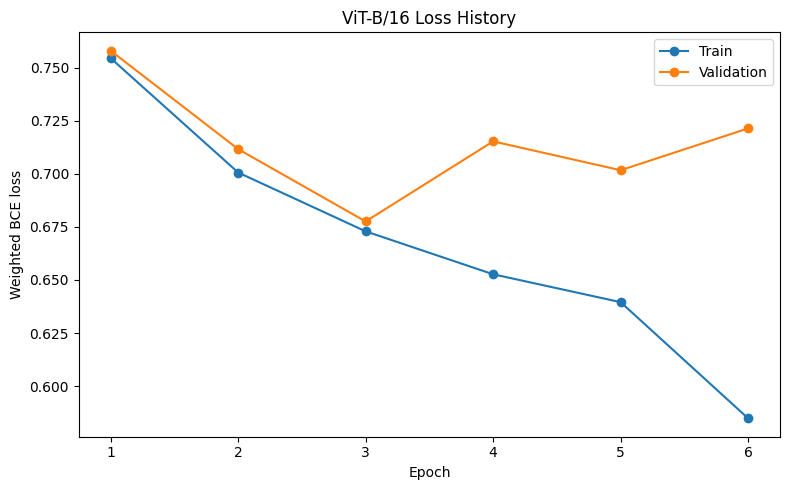

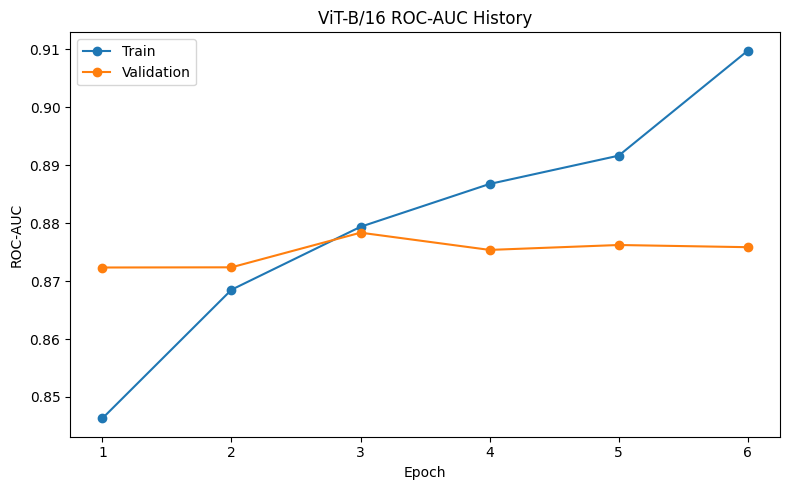

In [ ]:
history_df = pd.read_csv(HISTORY_PATH)

plt.figure(figsize=(8, 5))
plt.plot(history_df.epoch, history_df.train_loss, marker="o", label="Train")
plt.plot(history_df.epoch, history_df.val_loss, marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Weighted BCE loss")
plt.title("ViT-B/16 Loss History")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "loss_history.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df.epoch, history_df.train_auc, marker="o", label="Train")
plt.plot(history_df.epoch, history_df.val_auc, marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("ViT-B/16 ROC-AUC History")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "roc_auc_history.png", dpi=160)
plt.show()


### 3.6 Reload the best checkpoint and select the decision threshold

The classification threshold is selected on validation data only by maximum F1. The held-out test set is not used for model or threshold selection.


,best_epoch,validation_roc_auc,selected_threshold,validation_f1_at_selected_threshold
0,3,0.878365,0.57,0.646125


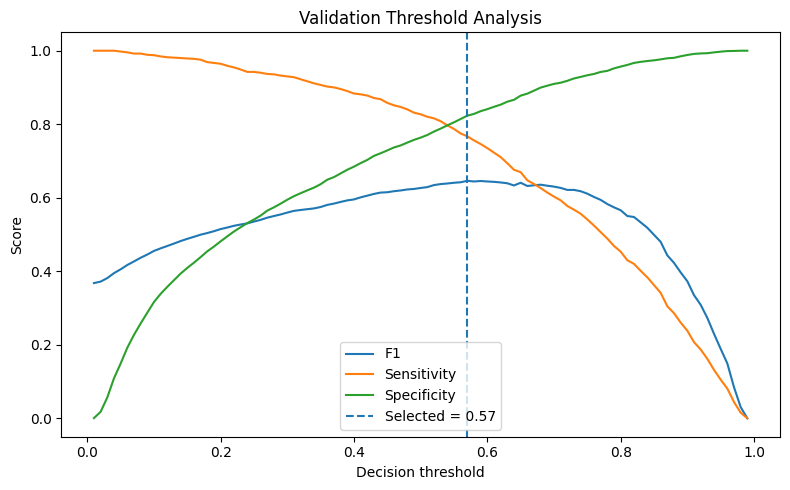

In [ ]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

val_best = run_epoch(model, val_loader, criterion)
val_predictions = pd.DataFrame({
    "patientId": val_best["patient_ids"],
    "target": val_best["targets"],
    "probability": val_best["probabilities"],
})
val_predictions.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)

threshold_rows = []
for threshold in np.arange(0.01, 1.00, 0.01):
    metrics = calculate_metrics(val_best["targets"], val_best["probabilities"], threshold)
    threshold_rows.append({"threshold": float(threshold), **metrics})

threshold_df = pd.DataFrame(threshold_rows)
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
FINAL_THRESHOLD = float(best_row["threshold"])
threshold_df.to_csv(OUTPUT_DIR / "validation_threshold_search.csv", index=False)

with open(THRESHOLD_PATH, "w") as f:
    json.dump({
        "threshold": FINAL_THRESHOLD,
        "selection_metric": "validation F1",
        "best_epoch": int(checkpoint["epoch"]),
        "best_validation_roc_auc": float(checkpoint["best_val_auc"]),
    }, f, indent=2)

summary = pd.DataFrame([{
    "best_epoch": int(checkpoint["epoch"]),
    "validation_roc_auc": val_best["roc_auc"],
    "selected_threshold": FINAL_THRESHOLD,
    "validation_f1_at_selected_threshold": best_row["f1"],
}])
summary.to_csv(OUTPUT_DIR / "best_model_validation_summary.csv", index=False)
display(summary)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df.threshold, threshold_df.f1, label="F1")
plt.plot(threshold_df.threshold, threshold_df.recall_sensitivity, label="Sensitivity")
plt.plot(threshold_df.threshold, threshold_df.specificity, label="Specificity")
plt.axvline(FINAL_THRESHOLD, linestyle="--", label=f"Selected = {FINAL_THRESHOLD:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Analysis")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "validation_threshold_analysis.png", dpi=160)
plt.show()


## 4. Test Evaluation

### 4.1 Predictions and final metrics

All reported test metrics use the best validation-ROC-AUC checkpoint and the threshold frozen on the validation set.


In [ ]:
if THRESHOLD_PATH.exists():
    with open(THRESHOLD_PATH) as f:
        FINAL_THRESHOLD = float(json.load(f)["threshold"])

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_result = run_epoch(model, test_loader, criterion)
y_true = test_result["targets"]
y_prob = test_result["probabilities"]
y_pred = (y_prob >= FINAL_THRESHOLD).astype(int)

final_metrics = {
    "test_loss": test_result["loss"],
    **calculate_metrics(y_true, y_prob, FINAL_THRESHOLD),
    "decision_threshold": FINAL_THRESHOLD,
}

metrics_df = pd.DataFrame(final_metrics.items(), columns=["metric", "value"])
metrics_df.to_csv(OUTPUT_DIR / "test_metrics.csv", index=False)
with open(OUTPUT_DIR / "test_metrics.json", "w") as f:
    json.dump({k: float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v for k, v in final_metrics.items()}, f, indent=2)

predictions_df = pd.DataFrame({
    "patientId": test_result["patient_ids"],
    "target": y_true,
    "probability": y_prob,
    "prediction": y_pred,
})
predictions_df = predictions_df.merge(
    test_df[["patientId", "detailed_class", "num_pneumonia_boxes"]],
    on="patientId", how="left"
)
predictions_df["error_type"] = np.select(
    [
        (predictions_df.target == 1) & (predictions_df.prediction == 1),
        (predictions_df.target == 0) & (predictions_df.prediction == 0),
        (predictions_df.target == 0) & (predictions_df.prediction == 1),
        (predictions_df.target == 1) & (predictions_df.prediction == 0),
    ],
    ["True Positive", "True Negative", "False Positive", "False Negative"],
    default="Other",
)
predictions_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
display(metrics_df)


,metric,value
0,test_loss,0.660005
1,roc_auc,0.885048
2,average_precision_pr_auc,0.698398
3,accuracy,0.811891
4,balanced_accuracy,0.799970
5,precision_ppv,0.559363
6,recall_sensitivity,0.778271
7,specificity,0.821670
8,negative_predictive_value,0.927220
9,f1,0.650904


### 4.2 Confusion matrix


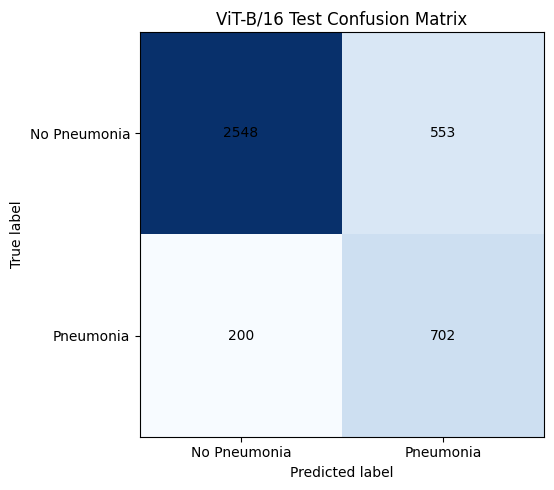

In [ ]:
tn = final_metrics["true_negative"]
fp = final_metrics["false_positive"]
fn = final_metrics["false_negative"]
tp = final_metrics["true_positive"]
cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("ViT-B/16 Test Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["No Pneumonia", "Pneumonia"])
plt.yticks([0, 1], ["No Pneumonia", "Pneumonia"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig(PLOT_DIR / "test_confusion_matrix.png", dpi=160)
plt.show()


### 4.3 ROC and precision-recall curves


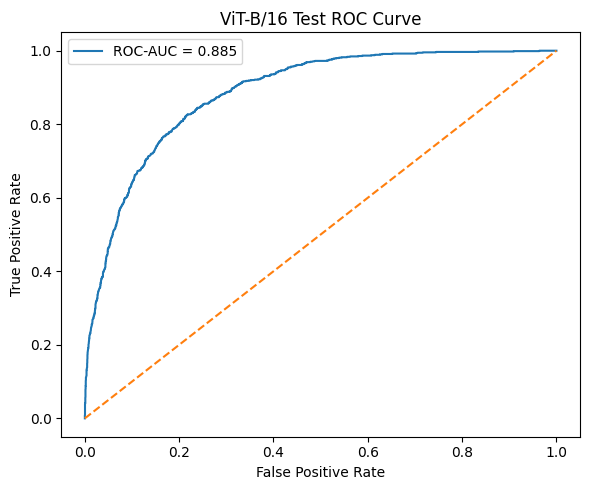

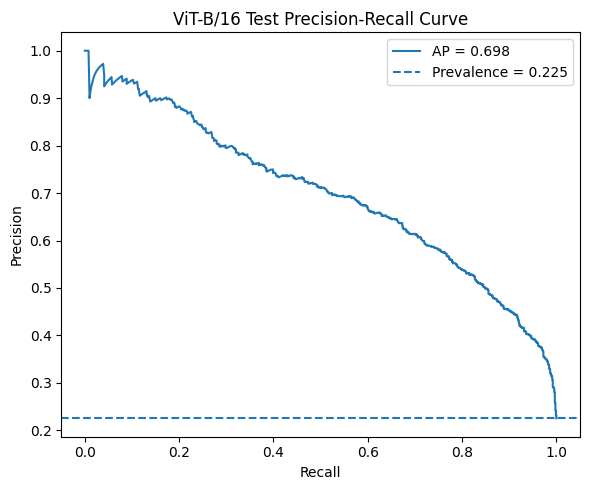

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {final_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ViT-B/16 Test ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "test_roc_curve.png", dpi=160)
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"AP = {final_metrics['average_precision_pr_auc']:.3f}")
plt.axhline(y_true.mean(), linestyle="--", label=f"Prevalence = {y_true.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("ViT-B/16 Test Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "test_precision_recall_curve.png", dpi=160)
plt.show()


### 4.4 Probability distribution and calibration

Probability separation shows how confidently the model distinguishes classes. Calibration compares predicted probability with observed pneumonia frequency.


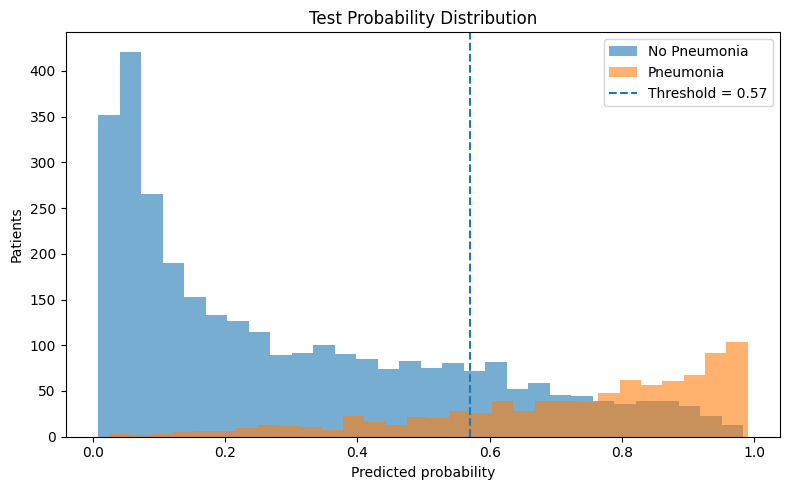

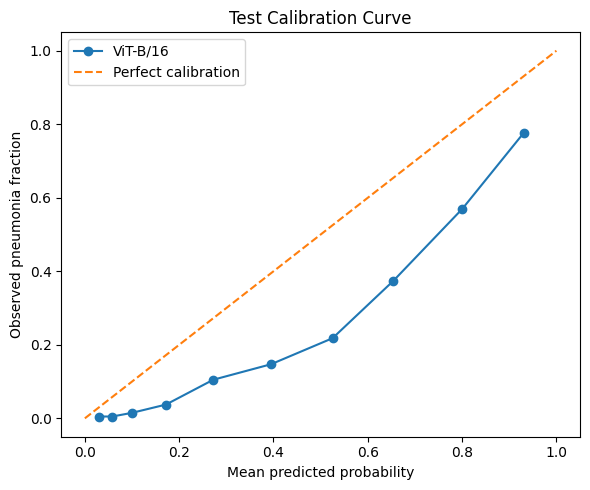

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(y_prob[y_true == 0], bins=30, alpha=0.6, label="No Pneumonia")
plt.hist(y_prob[y_true == 1], bins=30, alpha=0.6, label="Pneumonia")
plt.axvline(FINAL_THRESHOLD, linestyle="--", label=f"Threshold = {FINAL_THRESHOLD:.2f}")
plt.xlabel("Predicted probability")
plt.ylabel("Patients")
plt.title("Test Probability Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "test_probability_distribution.png", dpi=160)
plt.show()

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
calibration_df = pd.DataFrame({"mean_predicted_probability": prob_pred, "observed_fraction_positive": prob_true})
calibration_df.to_csv(OUTPUT_DIR / "test_calibration.csv", index=False)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="ViT-B/16")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed pneumonia fraction")
plt.title("Test Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "test_calibration_curve.png", dpi=160)
plt.show()


### 4.5 Error and diagnostic-subgroup analysis

The negative class contains both normal radiographs and abnormal radiographs without pneumonia opacity. Reporting these groups separately helps identify where false positives occur.


,detailed_class,samples,target_positive,predicted_positive,correct,errors,error_rate
0,Lung Opacity,902,902,702,702,200,0.221729
1,No Lung Opacity / Not Normal,1780,0,544,1236,544,0.305618
2,Normal,1321,0,9,1312,9,0.006813


,error_type,count
0,True Negative,2548
1,True Positive,702
2,False Positive,553
3,False Negative,200


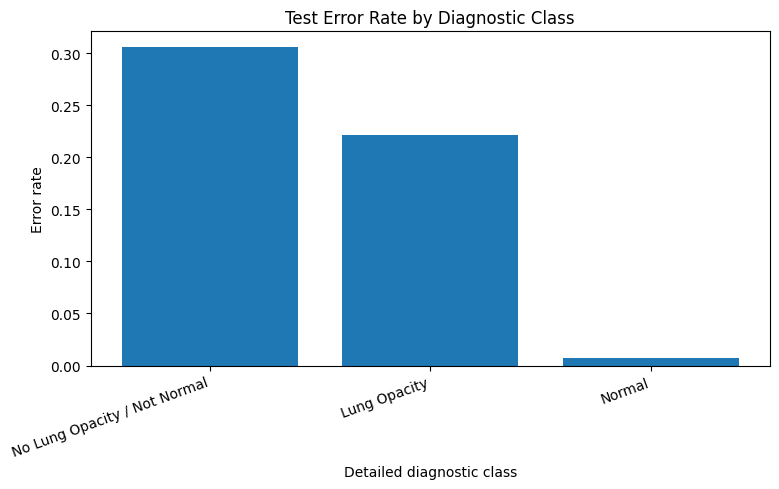

In [ ]:
subgroup_summary = (
    predictions_df.groupby("detailed_class", dropna=False)
    .agg(
        samples=("patientId", "size"),
        target_positive=("target", "sum"),
        predicted_positive=("prediction", "sum"),
        correct=("error_type", lambda s: s.isin(["True Positive", "True Negative"]).sum()),
    )
    .reset_index()
)
subgroup_summary["errors"] = subgroup_summary["samples"] - subgroup_summary["correct"]
subgroup_summary["error_rate"] = subgroup_summary["errors"] / subgroup_summary["samples"]
subgroup_summary.to_csv(OUTPUT_DIR / "test_subgroup_error_summary.csv", index=False)

error_summary = predictions_df["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")
error_summary.to_csv(OUTPUT_DIR / "test_error_summary.csv", index=False)

display(subgroup_summary)
display(error_summary)

plot_df = subgroup_summary.sort_values("error_rate", ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(plot_df["detailed_class"], plot_df["error_rate"])
plt.ylabel("Error rate")
plt.xlabel("Detailed diagnostic class")
plt.title("Test Error Rate by Diagnostic Class")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "test_error_rate_by_diagnostic_class.png", dpi=160)
plt.show()


## 5. Explainability

### 5.1 ViT self-attention

Attention from the final transformer block is visualized as CLS-to-patch attention averaged across heads. This is an attention visualization, not a lesion detector. RSNA bounding boxes are shown only as reference annotations for pneumonia-positive cases.


In [ ]:
raw_labels = pd.read_csv(LABELS_PATH)
raw_labels["patientId"] = raw_labels["patientId"].astype(str)
positive_boxes = raw_labels[
    (raw_labels["Target"] == 1) &
    raw_labels[["x", "y", "width", "height"]].notna().all(axis=1)
].copy()

def load_original_xray(image_path):
    ds = pydicom.dcmread(image_path)
    image = ds.pixel_array.astype(np.float32)
    bits_stored = int(getattr(ds, "BitsStored", 8))
    scale = float((2 ** bits_stored) - 1)
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        image = scale - image
    return np.clip(image / scale, 0.0, 1.0)

def get_last_block_attention(model, input_tensor):
    block = model.encoder.layers[-1]
    mha = block.self_attention
    original_forward = mha.forward
    captured = {}

    def wrapped_forward(*args, **kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        output, weights = original_forward(*args, **kwargs)
        captured["weights"] = weights.detach()
        return output, weights

    mha.forward = wrapped_forward
    try:
        model.eval()
        with torch.no_grad():
            logit = model(input_tensor).reshape(-1)[0]
            probability = torch.sigmoid(logit).item()
    finally:
        mha.forward = original_forward

    if "weights" not in captured:
        raise RuntimeError("Attention weights were not captured.")

    attention = captured["weights"][0]
    cls_to_patch = attention[:, 0, 1:].mean(dim=0)
    grid_size = int(np.sqrt(cls_to_patch.numel()))
    attention_map = cls_to_patch.reshape(1, 1, grid_size, grid_size)
    attention_map = F.interpolate(
        attention_map, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False
    )[0, 0].cpu().numpy()

    amin, amax = attention_map.min(), attention_map.max()
    attention_map = (attention_map - amin) / (amax - amin) if amax > amin else np.zeros_like(attention_map)
    return probability, attention_map

def explain_patient(patient_id):
    rows = test_df[test_df["patientId"] == patient_id]
    if len(rows) != 1:
        raise ValueError(f"Expected exactly one test row for {patient_id}.")

    idx = rows.index[0]
    row = test_df.loc[idx]
    sample = test_dataset[idx]
    input_tensor = sample["image"].unsqueeze(0).to(DEVICE)
    probability, attention_224 = get_last_block_attention(model, input_tensor)
    prediction = int(probability >= FINAL_THRESHOLD)
    true_label = int(row["Target"])

    original = load_original_xray(row["image_path"])
    attention_full = F.interpolate(
        torch.tensor(attention_224)[None, None].float(),
        size=original.shape, mode="bilinear", align_corners=False
    )[0, 0].numpy()
    boxes = positive_boxes[positive_boxes["patientId"] == patient_id]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(original, cmap="gray")
    axes[0].set_title(f"Original X-ray\nTrue: {'Pneumonia' if true_label else 'No Pneumonia'}")

    axes[1].imshow(original, cmap="gray")
    for _, box in boxes.iterrows():
        axes[1].add_patch(Rectangle((box.x, box.y), box.width, box.height, fill=False, linewidth=2))
    axes[1].set_title(f"RSNA Ground-Truth Boxes\nBoxes: {len(boxes)}")

    axes[2].imshow(attention_full, cmap="jet", vmin=0, vmax=1)
    axes[2].set_title("ViT Last-Block Attention")

    axes[3].imshow(original, cmap="gray")
    axes[3].imshow(attention_full, cmap="jet", alpha=0.40, vmin=0, vmax=1)
    for _, box in boxes.iterrows():
        axes[3].add_patch(Rectangle((box.x, box.y), box.width, box.height, fill=False, linewidth=2))
    axes[3].set_title(
        f"Attention + RSNA Boxes\nPred: {'Pneumonia' if prediction else 'No Pneumonia'} | P={probability:.3f}"
    )

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(EXPLAIN_DIR / f"{patient_id}_attention.png", dpi=160, bbox_inches="tight")
    plt.show()

    return {
        "patientId": patient_id,
        "true_label": true_label,
        "predicted_probability": probability,
        "decision_threshold": FINAL_THRESHOLD,
        "prediction": prediction,
        "ground_truth_boxes": len(boxes),
    }


### 5.2 Representative prediction outcomes

One confident example is selected for each available TP, TN, FP and FN outcome. These cases are for qualitative interpretation only.


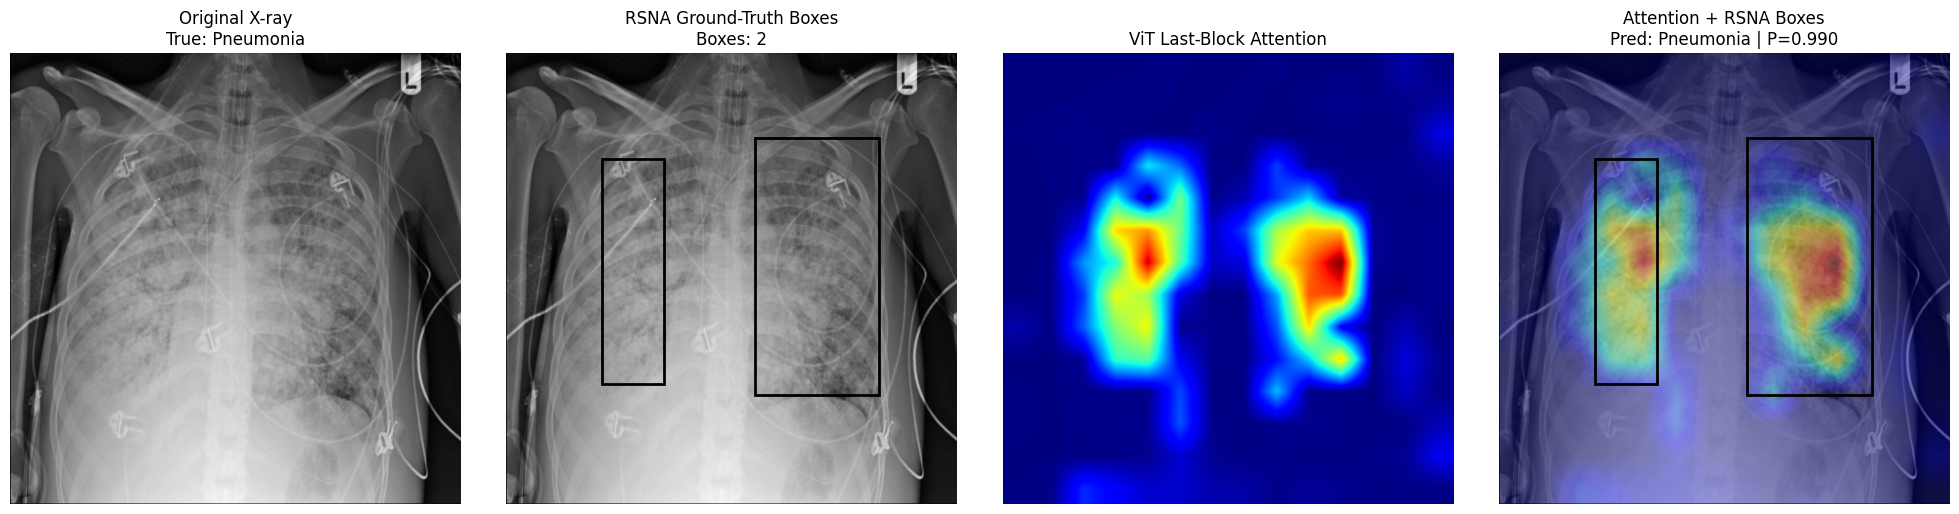

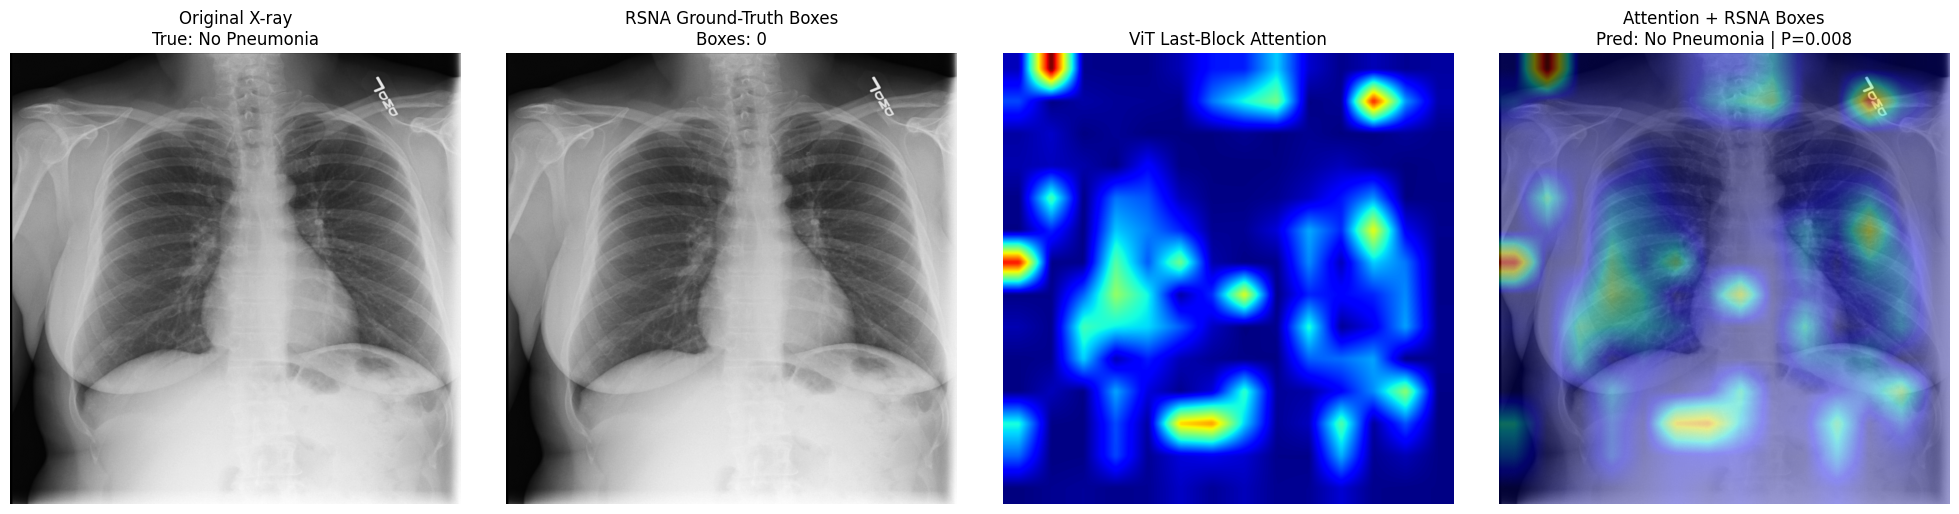

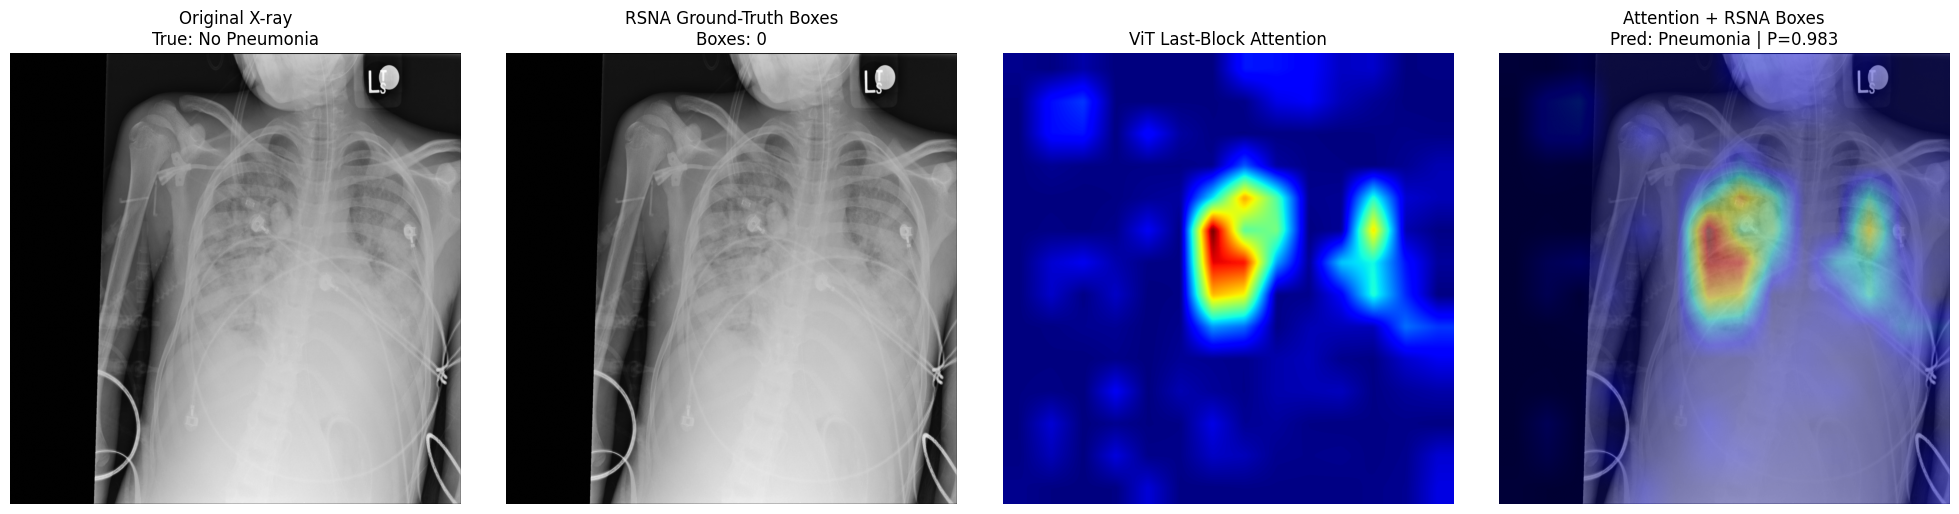

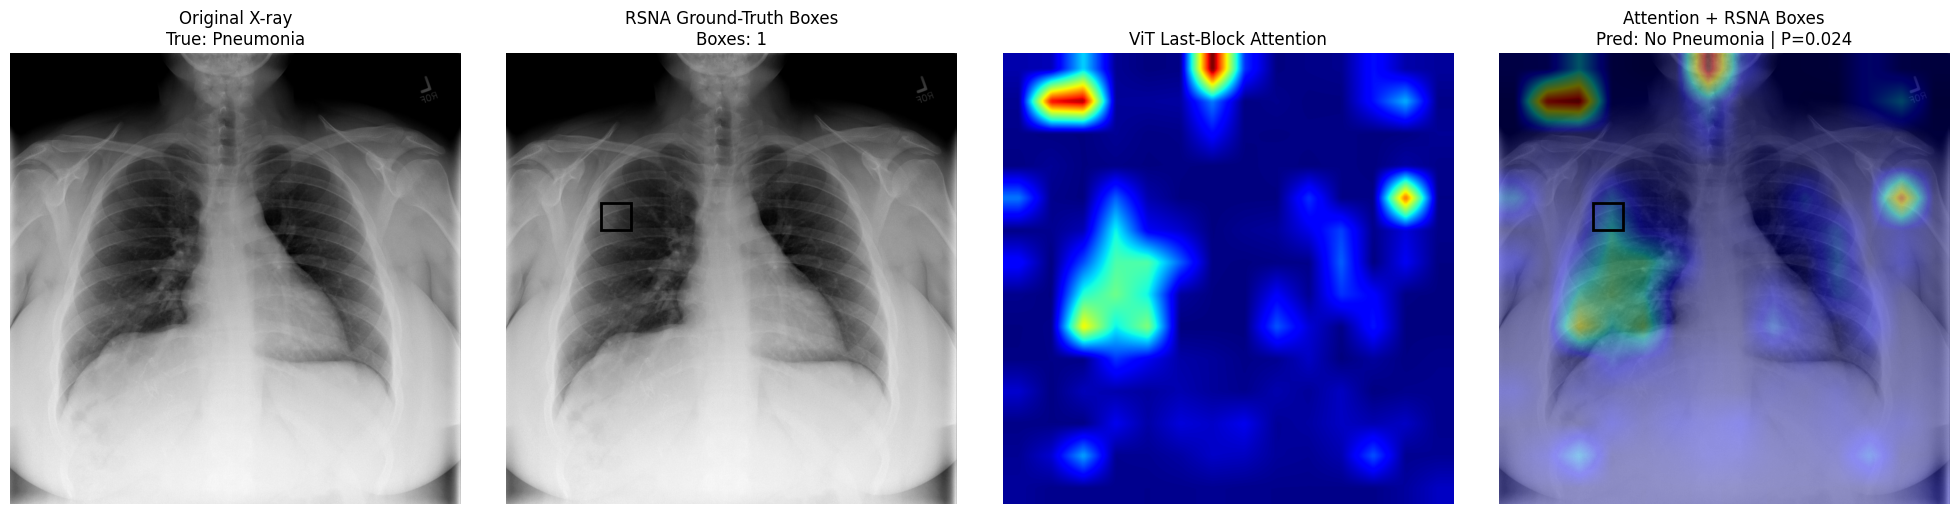

,patientId,true_label,predicted_probability,decision_threshold,prediction,ground_truth_boxes,outcome
0,d667579e-aa2d-461e-a869-4799ad466add,1,0.989514,0.57,1,2,True Positive
1,c9b6be50-6b97-493a-a306-e6426fde2d76,0,0.007817,0.57,0,0,True Negative
2,4ef41ff0-2671-4b4d-8492-90aad883e126,0,0.983371,0.57,1,0,False Positive
3,2dce719f-1702-406f-a471-03f033f1822a,1,0.023891,0.57,0,1,False Negative


In [ ]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

if THRESHOLD_PATH.exists():
    with open(THRESHOLD_PATH) as f:
        FINAL_THRESHOLD = float(json.load(f)["threshold"])

if not (OUTPUT_DIR / "test_predictions.csv").exists():
    raise FileNotFoundError("Run held-out test evaluation before explainability.")

explain_df = pd.read_csv(OUTPUT_DIR / "test_predictions.csv")
selected = []
for outcome in ["True Positive", "True Negative", "False Positive", "False Negative"]:
    subset = explain_df[explain_df["error_type"] == outcome].copy()
    if subset.empty:
        continue

    if outcome in ["True Positive", "False Positive"]:
        chosen = subset.sort_values("probability", ascending=False).iloc[0]
    else:
        chosen = subset.sort_values("probability", ascending=True).iloc[0]

    result = explain_patient(chosen.patientId)
    result["outcome"] = outcome
    selected.append(result)

representative_cases = pd.DataFrame(selected)
representative_cases.to_csv(EXPLAIN_DIR / "representative_cases.csv", index=False)
display(representative_cases)


## 6. Saved Artifacts

Checkpoints, histories, predictions, metrics, plots and explainability outputs are saved during the pipeline so downstream analysis does not require retraining.


In [ ]:
artifact_rows = []
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        artifact_rows.append({
            "artifact": str(path.relative_to(OUTPUT_DIR)),
            "size_mb": path.stat().st_size / (1024 ** 2),
        })

artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(OUTPUT_DIR / "artifact_inventory.csv", index=False)
display(artifact_inventory)
print("Artifacts saved under:", OUTPUT_DIR)


,artifact,size_mb
0,best_model_validation_summary.csv,0.000136
1,explainability/2dce719f-1702-406f-a471-03f033f...,1.106936
2,explainability/4ef41ff0-2671-4b4d-8492-90aad88...,1.016041
3,explainability/c9b6be50-6b97-493a-a306-e6426fd...,1.250766
4,explainability/d667579e-aa2d-461e-a869-4799ad4...,1.252198
5,explainability/representative_cases.csv,0.000463
6,models/vit_b16_best.pth,982.082089
7,models/vit_b16_last.pth,982.083005
8,plots/loss_history.png,0.066793
9,plots/roc_auc_history.png,0.052837


Artifacts saved under: /kaggle/working/rsna_outputs/vit
